# 1 Preliminary questions

Question 1

In [177]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def plot_image(X):
    cmap = LinearSegmentedColormap.from_list(
        'custom',
        ['white', 'blue', 'red']
    )
    
    plt.imshow(X, cmap=cmap, vmin=0, vmax=1)
    plt.show()

Question 2

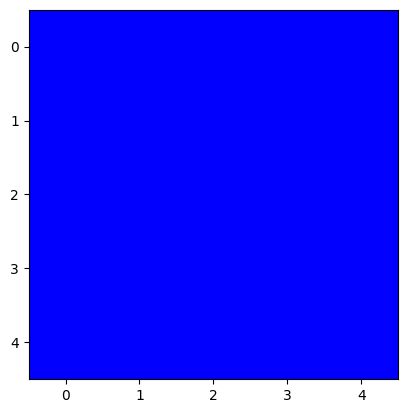

In [178]:
# Exemple d'utilisation de la fonction afficher_image
import numpy as np

#an  array where all the value are 0.5
X = np.full((5, 5), 0.5)
plot_image(X)

Question 3

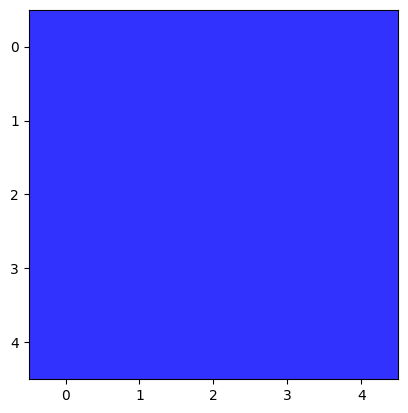

In [179]:
# Exemple d'utilisation de la fonction afficher_image
import numpy as np

#an  array where all the value are 0.5
X = np.full((5, 5), 0.4)
plot_image(X)

Question 4

lorsque on ne precise pas les parametres vmin et vmax, les couleurs ne change pas, independamment de la valeur 

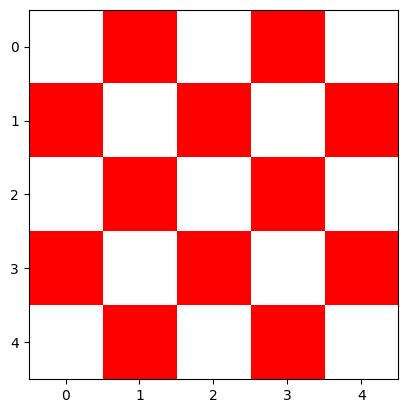

In [180]:
#array de 0 et 1 alternées de taille 5*5 
X = np.array([[0, 1, 0, 1, 0],
                [1, 0, 1, 0, 1],
                [0, 1, 0, 1, 0],
                [1, 0, 1, 0, 1],
                [0, 1, 0, 1, 0]])
plot_image(X)

Question 5

une image de R(p*p) peut etre representé comme un vecteur ou on concatene les colones horizontalement de façon a obtenir un vecteur d'une colonne

Question 6

sa dimension est  p au carré

Question 7

In [181]:
# Implementation de la fonction image_to_vector
def image_to_vector(X):
    return X.T.flatten()

X = np.array([[4, 11, 0,],
                [12, 50, 10],
                [0, 10, 0]])    
image_to_vector(X)

array([ 4, 12,  0, 11, 50, 10,  0, 10,  0])

Question 8

In [182]:
# Implementation de la fonction vector_to_image
def vector_to_image(x, p):
    return x.reshape((p, p)).T

vector_to_image(image_to_vector(X), 3)

array([[ 4, 11,  0],
       [12, 50, 10],
       [ 0, 10,  0]])

Question 9

In [183]:
np.array_equal(X, vector_to_image(image_to_vector(X), 3))

True

# 2 On chess-like images


In [267]:
p = 5

Question 10

l'ensemble des echequiers est un espace vectoriel car il peut etre engendré par deux vecteur bien definis

Question 11

ici k = 2, une base orthogonale peut etre s1 et s2 defini comme suit

In [268]:
s1 = image_to_vector(np.array([[0, 1, 0, 1, 0],
                [1, 0, 1, 0, 1],
                [0, 1, 0, 1, 0],
                [1, 0, 1, 0, 1],
                [0, 1, 0, 1, 0]]))

s2 = image_to_vector(np.array([[1, 0, 1, 0, 1],    
                [0, 1, 0, 1, 0],
                [1, 0, 1, 0, 1],
                [0, 1, 0, 1, 0],
                [1, 0, 1, 0, 1]]))

In [269]:
S = np.column_stack((s1, s2))
S.shape

(25, 2)

Question 12

In [270]:
def create_element(a,b):
    return a*s2 + b*s1

### 2.1 On exact recovery with pixel picking

Question 13

n = p*p = 25 ; m = 2

Question 14

In [271]:
# implementation du sensing operator
def sensing_matrix(m,n):
    a = np.zeros((m, n))
    for i in range(m):
        a[i, i] = 1
    return a

sensing_matrix(3, 4) 

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.]])

Question 15

In [272]:
X = create_element(1, 0.5)
Y = sensing_matrix(2, 25) @ image_to_vector(X)
Y

array([1. , 0.5])

In [273]:
sensing_matrix(2, 25)
X

array([1. , 0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. ,
       0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. ])

Question 16

In [283]:
#decodeur 1 (pseudo inverse)
def decoder_1(Y, k=2 ):
    M = sensing_matrix(k, 25)
    return np.linalg.pinv(M) @ Y

In [284]:
#decoder_2 (moindres carrés)
def decoder_2(Y, k=2 ):
    M = sensing_matrix(k, 25)
    S = np.column_stack((s1, s2))
    P = np.linalg.pinv(M @ S)
    return  S @ P @ Y

Question 17

In [285]:
Y1 = decoder_1(Y)
Y1

array([1. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ])

In [286]:
Y2 = decoder_2(Y)
Y2

array([1. , 0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. ,
       0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. , 0.5, 1. ])

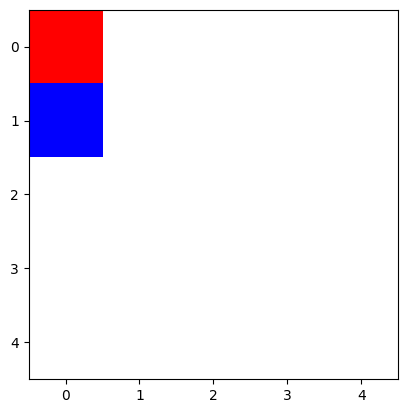

In [287]:
plot_image(vector_to_image(Y1,5))

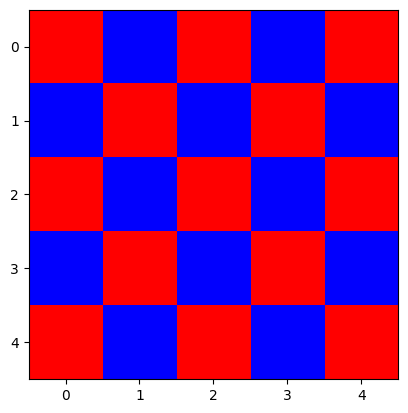

In [288]:
plot_image(vector_to_image(Y2,5))

Question 18

full rang signifie que les colonnes de MS sont linéairement indépendantes  ;l'application definie par MS est injective'

Question 19

lorsque m>2 la reconstruction devient plus stable et robuste.

Question 20

In [302]:
# fonction SNR
def SNR(m, signal, decoder=decoder_1):
    Ps = np.mean(signal**2)
    signal_reconstructed = decoder(sensing_matrix(m, 25) @ image_to_vector(signal), m)
    noise = signal - signal_reconstructed
    Pn = np.mean(noise**2)
    return 10 * np.log10(Ps / Pn)

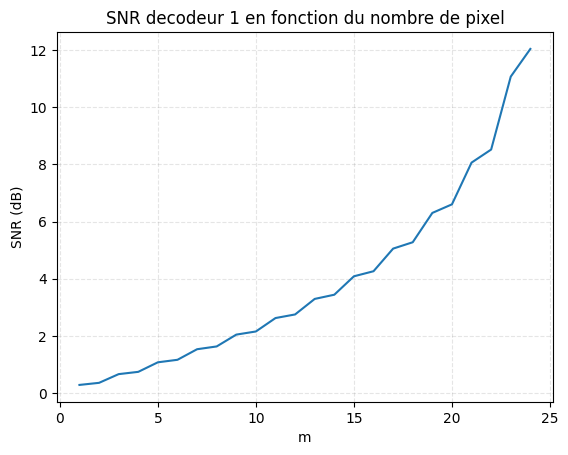

In [ ]:
# plot SNR for m  in range 1 to 25
m_values = range(1, 25)
SNR_values = [SNR(m, X) for m in m_values]
plt.plot(m_values, SNR_values)
plt.title('SNR decodeur 1 en fonction du nombre de pixel')
plt.xlabel('m')
plt.ylabel('SNR (dB)')
plt.grid(linestyle='--', color='gray' , alpha = 0.2)




C:\Users\STEEVE\AppData\Local\Temp\ipykernel_7200\222174478.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10(Ps / Pn)


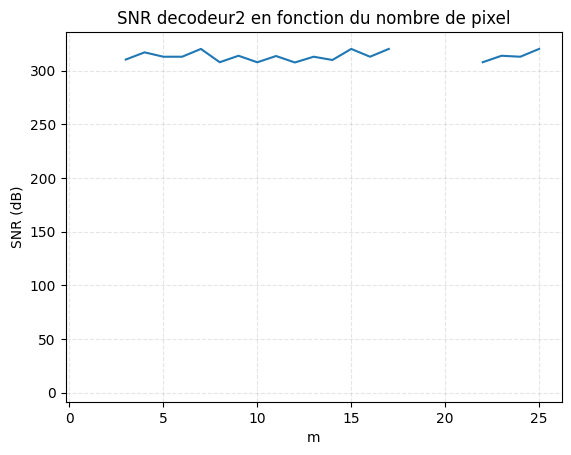

In [310]:
# plot SNR for m  in range 1 to 25
m_values = range(1, 26)
SNR_values = [SNR(m, X, decoder_2) for m in m_values]
plt.plot(m_values, SNR_values)
plt.title('SNR decodeur2 en fonction du nombre de pixel')
plt.xlabel('m')
plt.ylabel('SNR (dB)')
plt.grid(linestyle='--', color='gray' , alpha = 0.2)

In [313]:
SNR(3, X, decoder_2)

np.float64(310.4511366129177)

### A more general sensing matrix


Question 21


In [344]:
# sensing operator from gaussian distribution
def sensing_matrix_gaussian(m, n):
    return np.random.randn(m, n)

In [345]:
# decoder 1 avec une matrice de sensing gaussienne
def decoder_1_gaussian(Y, k=2 ):
    M = sensing_matrix_gaussian(k, 25)
    return np.linalg.pinv(M) @ Y

In [346]:
#decoder_2  avec une matrice de sensing gaussienne
def decoder_2_gaussian(Y, k=2 ):
    M = sensing_matrix_gaussian(k, 25)
    S = np.column_stack((s1, s2))
    P = np.linalg.pinv(M @ S)
    return  S @ P @ Y

In [347]:
Y1_gaussian = decoder_1_gaussian(Y)
Y1_gaussian

array([-1.19639349e-02,  4.20911693e-02,  5.09756854e-02,  4.06894942e-02,
       -6.74733288e-03, -1.95406982e-02,  3.23306442e-02, -5.88211834e-03,
        5.49461606e-02,  6.94898063e-02, -4.46215603e-02,  5.82800356e-02,
       -3.54691885e-02,  1.70771288e-02, -1.60807834e-02, -5.84153110e-02,
        1.10570975e-05,  8.25029265e-02, -2.39529726e-02,  1.69923249e-02,
        1.33712325e-02,  7.12854581e-02,  7.25389614e-03, -1.35577620e-03,
       -6.22089074e-02])

In [348]:
Y2_gaussian = decoder_2_gaussian(Y)
Y2_gaussian

array([0.05512057, 0.18658766, 0.05512057, 0.18658766, 0.05512057,
       0.18658766, 0.05512057, 0.18658766, 0.05512057, 0.18658766,
       0.05512057, 0.18658766, 0.05512057, 0.18658766, 0.05512057,
       0.18658766, 0.05512057, 0.18658766, 0.05512057, 0.18658766,
       0.05512057, 0.18658766, 0.05512057, 0.18658766, 0.05512057])

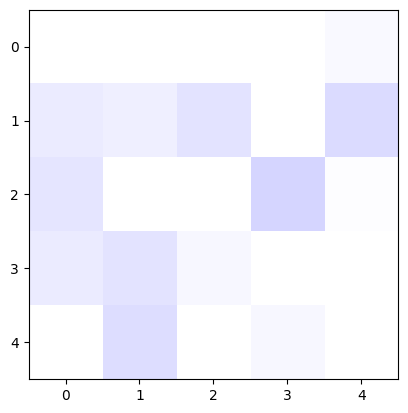

In [349]:
plot_image(vector_to_image(Y1_gaussian,5))

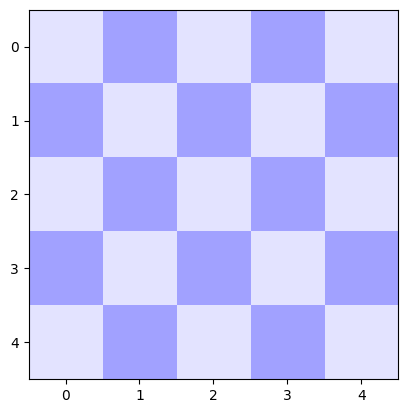

In [350]:
plot_image(vector_to_image(Y2_gaussian,5))

Question 22

In [351]:
# fonction SNR
def SNR(m, signal, decoder=decoder_1_gaussian):
    Ps = np.mean(signal**2)
    signal_reconstructed = decoder(sensing_matrix_gaussian(m, 25) @ image_to_vector(signal), m)
    noise = signal - signal_reconstructed
    Pn = np.mean(noise**2)
    return 10 * np.log10(Ps / Pn)

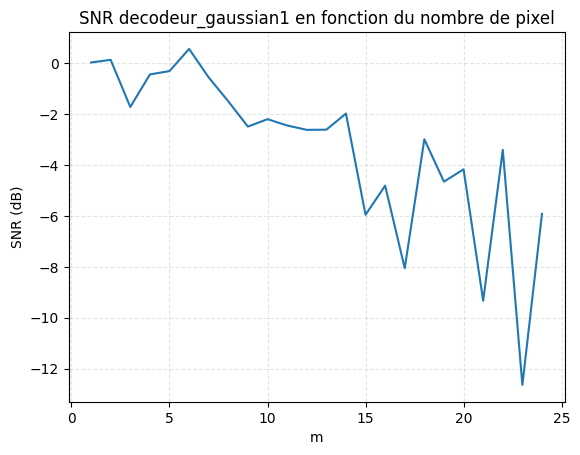

In [354]:
# plot SNR for m  in range 1 to 25
m_values = range(1, 25)
SNR_values = [SNR(m, X) for m in m_values]
plt.plot(m_values, SNR_values)
plt.title('SNR decodeur_gaussian1 en fonction du nombre de pixel')
plt.xlabel('m')
plt.ylabel('SNR (dB)')
plt.grid(linestyle='--', color='gray' , alpha = 0.2)

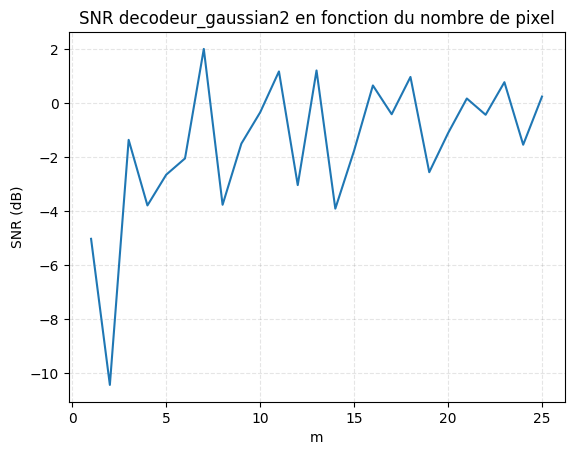

In [355]:
# plot SNR for m  in range 1 to 25
m_values = range(1, 26)
SNR_values = [SNR(m, X, decoder_2_gaussian) for m in m_values]
plt.plot(m_values, SNR_values)
plt.title('SNR decodeur_gaussian2 en fonction du nombre de pixel')
plt.xlabel('m')
plt.ylabel('SNR (dB)')
plt.grid(linestyle='--', color='gray' , alpha = 0.2)

### 2.3 About the robustness to noise


In [366]:
y_example = sensing_matrix(2,25) @ image_to_vector(X) + np.random.normal(0,0.5, size=(1,2))
y_example


array([[-0.04499839,  0.12149878]])

In [368]:
# fonction SNR
def SNR(m, signal, decoder=decoder_1_gaussian):
    noise = np.random.normal(0,0.5, size=(1, m))
    observation = sensing_matrix(m, 25) @ image_to_vector(signal) + noise
    Ps = np.mean(observation**2)
    Pn = np.mean(noise**2)
    return 10 * np.log10(Ps / Pn)

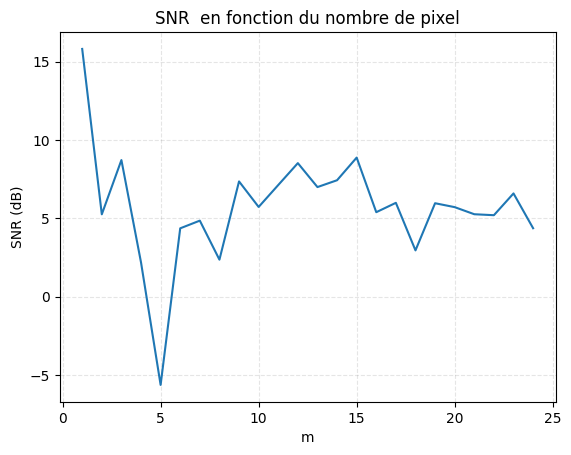

In [386]:
# plot SNR for m  in range 1 to 25
m_values = range(1, 25)
SNR_values = [SNR(m, X) for m in m_values]
plt.plot(m_values, SNR_values)
plt.title('SNR  en fonction du nombre de pixel')
plt.xlabel('m')
plt.ylabel('SNR (dB)')
plt.grid(linestyle='--', color='gray' , alpha = 0.2)